# Further Experiments

In [2]:
import numpy as np
import scipy.io as sio
import os
from sklearn.linear_model import RidgeCV, LogisticRegression
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

In [3]:
# For the .mat files (Experiment 2 and Experiment 3)
mat_exp3 = "/home/scur0412/NeuroNLP/data/participants/M02/data_243sentences.mat"
mat_exp2 = "/home/scur0412/NeuroNLP/data/participants/M02/data_384sentences.mat"

# For the embeddings directories (Experiment 2 and Experiment 3) for Qwen Embedder
embed_dir_exp2 = "/home/scur0412/NeuroNLP/results/embeddings/Qwen_Embedder/Experiment2_384"
embed_dir_exp3 = "/home/scur0412/NeuroNLP/results/embeddings/Qwen_Embedder/Experiment3_243"

# For the embeddings directories (Experiment 2 and Experiment 3) for Qwen
llm_dir_exp2 = "/home/scur0412/NeuroNLP/results/embeddings/Qwen/Experiment2_384"
llm_dir_exp3 = "/home/scur0412/NeuroNLP/results/embeddings/Qwen/Experiment3_243"
num_layers = 37

In [4]:
mat2 = sio.loadmat(mat_exp2)
mat3 = sio.loadmat(mat_exp3)

# fMRI activations
fmri_exp2 = mat2['examples_passagesentences']
fmri_exp3 = mat3['examples_passagesentences']

print("fMRI exp2:", fmri_exp2.shape)  
print("fMRI exp3:", fmri_exp3.shape)  

/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/scipy/io/matlab/_mio.py:227: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Consider mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


fMRI exp2: (384, 170712)
fMRI exp3: (243, 170712)


In [5]:
#Topic labels (for residual method) 
topic_labels_exp2 = mat2['labelsPassageCategory']
topic_labels_exp3 = mat3['labelsPassageCategory']

print("Topic labels exp2:", topic_labels_exp2.shape)
print("Sample:", topic_labels_exp2[:5])

# Sentence labels (for reference) 
sentences_exp2 = mat2['labelsSentences']
sentences_exp3 = mat3['labelsSentences']

# Passage-level grouping ─
# labelsPassageForEachSentence maps each sentence → its passage
passage_per_sentence_exp2 = mat2['labelsPassageForEachSentence']
passage_per_sentence_exp3 = mat3['labelsPassageForEachSentence']

Topic labels exp2: (96, 1)
Sample: [[18]
 [10]
 [12]
 [ 7]
 [23]]


In [6]:
#  Extract the 24 topic string names
key_cats = mat2['keyPassageCategory'].flatten()
topic_names = np.array([k[0] for k in key_cats])
print("Topic names:", topic_names)

# Map passages → topic index 
passage_to_topic_idx = mat2['labelsPassageCategory'].flatten() - 1 
print("Passage topic indices:", passage_to_topic_idx[:5]) 

# Map sentences → passage 
sentence_to_passage = mat2['labelsPassageForEachSentence'].flatten() - 1 
print("Sentence to passage:", sentence_to_passage[:5])

# Combine → topic label per sentence 
topic_idx_per_sentence = passage_to_topic_idx[sentence_to_passage]
topic_labels_exp2 = topic_names[topic_idx_per_sentence]

print("Shape:", topic_labels_exp2.shape)   
print("Sample:", topic_labels_exp2[:10])  

# Experiment 3 
key_cats3 = mat3['keyPassageCategory'].flatten()
topic_names3 = np.array([k[0] for k in key_cats3])
passage_to_topic_idx3 = mat3['labelsPassageCategory'].flatten() - 1
sentence_to_passage3 = mat3['labelsPassageForEachSentence'].flatten() - 1
topic_idx_per_sentence3 = passage_to_topic_idx3[sentence_to_passage3]
topic_labels_exp3 = topic_names3[topic_idx_per_sentence3]

print("Exp3 shape:", topic_labels_exp3.shape) 
print("Exp3 sample:", topic_labels_exp3[:10])

Topic names: ['animal' 'appliance' 'bird' 'body_part' 'building_part' 'clothing'
 'crime' 'disaster' 'drink_non_alcoholic' 'dwelling' 'fish' 'fruit'
 'furniture' 'human' 'insect' 'kitchen_utensil' 'landscape' 'music'
 'place' 'profession' 'tool' 'vegetable' 'vehicles_transport' 'weapon']
Passage topic indices: [17  9 11  6 22]
Sentence to passage: [0 0 0 0 1]
Shape: (384,)
Sample: ['music' 'music' 'music' 'music' 'dwelling' 'dwelling' 'dwelling'
 'dwelling' 'fruit' 'fruit']
Exp3 shape: (243,)
Exp3 sample: ['beekeeping' 'beekeeping' 'beekeeping' 'beekeeping' 'beekeeping'
 'beekeeping' 'beekeeping' 'beekeeping' 'beekeeping' 'beekeeping']


# Random Baseline

In [7]:
layer_embeddings_llm_exp2 = {}
layer_embeddings_llm_exp3 = {}
layer_embeddings_emb_exp2 = {}
layer_embeddings_emb_exp3 = {}

for layer_idx in range(num_layers):
    layer_embeddings_llm_exp2[layer_idx] = np.load(
        os.path.join(llm_dir_exp2, f"qwen_layer{layer_idx}.npy")
    )
    layer_embeddings_llm_exp3[layer_idx] = np.load(
        os.path.join(llm_dir_exp3, f"qwen_layer{layer_idx}.npy")
    )
    layer_embeddings_emb_exp2[layer_idx] = np.load(
        os.path.join(embed_dir_exp2, f"qwen_layer{layer_idx}.npy")
    )
    layer_embeddings_emb_exp3[layer_idx] = np.load(
        os.path.join(embed_dir_exp3, f"qwen_layer{layer_idx}.npy")
    )

print("LLM exp2 layer 0:", layer_embeddings_llm_exp2[0].shape)  # (384, n_dims)
print("LLM exp3 layer 0:", layer_embeddings_llm_exp3[0].shape)  # (243, n_dims)
print("Emb exp2 layer 0:", layer_embeddings_emb_exp2[0].shape)  # (384, n_dims)
print("Emb exp3 layer 0:", layer_embeddings_emb_exp3[0].shape)  # (243, n_dims)

LLM exp2 layer 0: (384, 4096)
LLM exp3 layer 0: (243, 4096)
Emb exp2 layer 0: (384, 4096)
Emb exp3 layer 0: (243, 4096)


In [8]:
def voxel_encoding(embeddings, fmri, n_splits=5):
    """Returns mean Pearson r across voxels."""
    kf = KFold(n_splits=n_splits)
    correlations = []

    for train_idx, test_idx in kf.split(embeddings):
        X_train, X_test = embeddings[train_idx], embeddings[test_idx]
        y_train, y_test = fmri[train_idx], fmri[test_idx]

        model = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        r_per_voxel = [
            np.corrcoef(y_pred[:, v], y_test[:, v])[0, 1]
            for v in range(fmri.shape[1])
        ]
        correlations.append(np.nanmean(r_per_voxel))

    return np.mean(correlations)

In [9]:
def random_baseline(embeddings, fmri, n_seeds=5):
    scores = []
    for seed in range(n_seeds):
        np.random.seed(seed)
        random_embeddings = np.random.randn(*embeddings.shape)
        scores.append(voxel_encoding(random_embeddings, fmri))
    return np.mean(scores)

In [10]:
peak_layer_exp2_llm = 17  
peak_layer_exp3_llm = 16
peak_layer_exp2_emb = 10
peak_layer_exp3_emb = 25  

# Exp2
random_score_exp2_llm = random_baseline(
    layer_embeddings_llm_exp2[peak_layer_exp2_llm], fmri_exp2
)
print(f"Random baseline exp2 llm: {random_score_exp2_llm:.4f}")

random_score_exp2_emb = random_baseline(
    layer_embeddings_emb_exp2[peak_layer_exp2_emb], fmri_exp2
)
print(f"Random baseline exp2 llm: {random_score_exp2_emb:.4f}")

# Exp3
random_score_exp3_llm = random_baseline(
    layer_embeddings_emb_exp3[peak_layer_exp3_llm], fmri_exp3
)
print(f"Random baseline exp3: {random_score_exp3_llm:.4f}")

random_score_exp3_emb = random_baseline(
    layer_embeddings_emb_exp3[peak_layer_exp3_emb], fmri_exp3
)
print(f"Random baseline exp3: {random_score_exp3_emb:.4f}")

Random baseline exp2 llm: -0.0084
Random baseline exp2 llm: -0.0084
Random baseline exp3: -0.0125
Random baseline exp3: -0.0125


RSA

In [11]:
def build_rdm(representations):
    distances = pdist(representations, metric='cosine')
    return squareform(distances)

def compare_rdms(rdm1, rdm2):
    idx = np.triu_indices(rdm1.shape[0], k=1)
    rho, p = spearmanr(rdm1[idx], rdm2[idx])
    return rho, p

def permutation_test(rdm1, rdm2, n_perms=1000):
    observed_rho, _ = compare_rdms(rdm1, rdm2)
    null = []
    for _ in range(n_perms):
        perm = np.random.permutation(rdm1.shape[0])
        rdm1_perm = rdm1[np.ix_(perm, perm)]
        null.append(compare_rdms(rdm1_perm, rdm2)[0])
    p_value = np.mean(np.array(null) >= observed_rho)
    return observed_rho, p_value

brain_rdm_exp2 = build_rdm(fmri_exp2)  
brain_rdm_exp3 = build_rdm(fmri_exp3)  
print("Brain RDM exp2:", brain_rdm_exp2.shape)
print("Brain RDM exp3:", brain_rdm_exp3.shape)

def build_topic_rdm(topic_labels):
    n = len(topic_labels)
    rdm = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            rdm[i, j] = 0 if topic_labels[i] == topic_labels[j] else 1
    return rdm

topic_rdm_exp2 = build_topic_rdm(topic_labels_exp2)
topic_rdm_exp3 = build_topic_rdm(topic_labels_exp3)

topic_brain_rho_exp2, _ = compare_rdms(topic_rdm_exp2, brain_rdm_exp2)
topic_brain_rho_exp3, _ = compare_rdms(topic_rdm_exp3, brain_rdm_exp3)
print(f"Topic→Brain RSA exp2: {topic_brain_rho_exp2:.4f}")
print(f"Topic→Brain RSA exp3: {topic_brain_rho_exp3:.4f}")

Brain RDM exp2: (384, 384)
Brain RDM exp3: (243, 243)
Topic→Brain RSA exp2: 0.0521
Topic→Brain RSA exp3: 0.0542


In [12]:
rsa_llm_exp2, rsa_emb_exp2 = {}, {}
rsa_llm_exp3, rsa_emb_exp3 = {}, {}

for layer in range(1, num_layers): 
    print(f"Layer {layer}...", end="\r")
    rsa_llm_exp2[layer] = compare_rdms(build_rdm(layer_embeddings_llm_exp2[layer]), brain_rdm_exp2)
    rsa_emb_exp2[layer] = compare_rdms(build_rdm(layer_embeddings_emb_exp2[layer]), brain_rdm_exp2)
    rsa_llm_exp3[layer] = compare_rdms(build_rdm(layer_embeddings_llm_exp3[layer]), brain_rdm_exp3)
    rsa_emb_exp3[layer] = compare_rdms(build_rdm(layer_embeddings_emb_exp3[layer]), brain_rdm_exp3)

print("RSA complete")

print(f"\nExp2 — LLM  peak: layer {max(rsa_llm_exp2, key=lambda l: rsa_llm_exp2[l][0])}, "
      f"rho={max(v[0] for v in rsa_llm_exp2.values()):.4f}")
print(f"Exp2 — Emb  peak: layer {max(rsa_emb_exp2, key=lambda l: rsa_emb_exp2[l][0])}, "
      f"rho={max(v[0] for v in rsa_emb_exp2.values()):.4f}")
print(f"Exp3 — LLM  peak: layer {max(rsa_llm_exp3, key=lambda l: rsa_llm_exp3[l][0])}, "
      f"rho={max(v[0] for v in rsa_llm_exp3.values()):.4f}")
print(f"Exp3 — Emb  peak: layer {max(rsa_emb_exp3, key=lambda l: rsa_emb_exp3[l][0])}, "
      f"rho={max(v[0] for v in rsa_emb_exp3.values()):.4f}")
sentence_to_passage3 = mat3['labelsPassageForEachSentence'].flatten() - 1
topic_idx_per_sentence3 = passage_to_topic_idx3[sentence_to_passage3]
topic_labels_exp3 = topic_names3[topic_idx_per_sentence3]

RSA complete

Exp2 — LLM  peak: layer 12, rho=0.0446
Exp2 — Emb  peak: layer 28, rho=0.0577
Exp3 — LLM  peak: layer 22, rho=0.1058
Exp3 — Emb  peak: layer 16, rho=0.0977


In [13]:
def compute_residual_embeddings(embeddings, topic_labels):
    """
    Project out topic-predictive directions from embeddings.
    Returns residual embeddings uninformative about broad topic.
    """
    le = LabelEncoder()
    y = le.fit_transform(topic_labels)

    # Train linear classifier to find topic subspace
    clf = LogisticRegression(max_iter=1000, C=1.0)
    clf.fit(embeddings, y)
    topic_subspace = clf.coef_  

    # Orthogonal projection — remove topic directions
    W = topic_subspace  
    WWT_inv = np.linalg.pinv(W @ W.T)
    projection = (W.T @ WWT_inv @ W @ embeddings.T).T

    residuals = embeddings - projection
    return residuals

In [ ]:
residual_embeddings_llm_exp2 = {}
residual_embeddings_emb_exp2 = {}
residual_embeddings_llm_exp3 = {}
residual_embeddings_emb_exp3 = {}

for layer in range(37):
    residual_embeddings_llm_exp2[layer] = compute_residual_embeddings(
        layer_embeddings_llm_exp2[layer], topic_labels_exp2
    )
    residual_embeddings_emb_exp2[layer] = compute_residual_embeddings(
        layer_embeddings_emb_exp2[layer], topic_labels_exp2
    )

for layer in range(37):
    residual_embeddings_llm_exp3[layer] = compute_residual_embeddings(
        layer_embeddings_llm_exp3[layer], topic_labels_exp3
    )
    residual_embeddings_emb_exp3[layer] = compute_residual_embeddings(
        layer_embeddings_emb_exp3[layer], topic_labels_exp3
    )

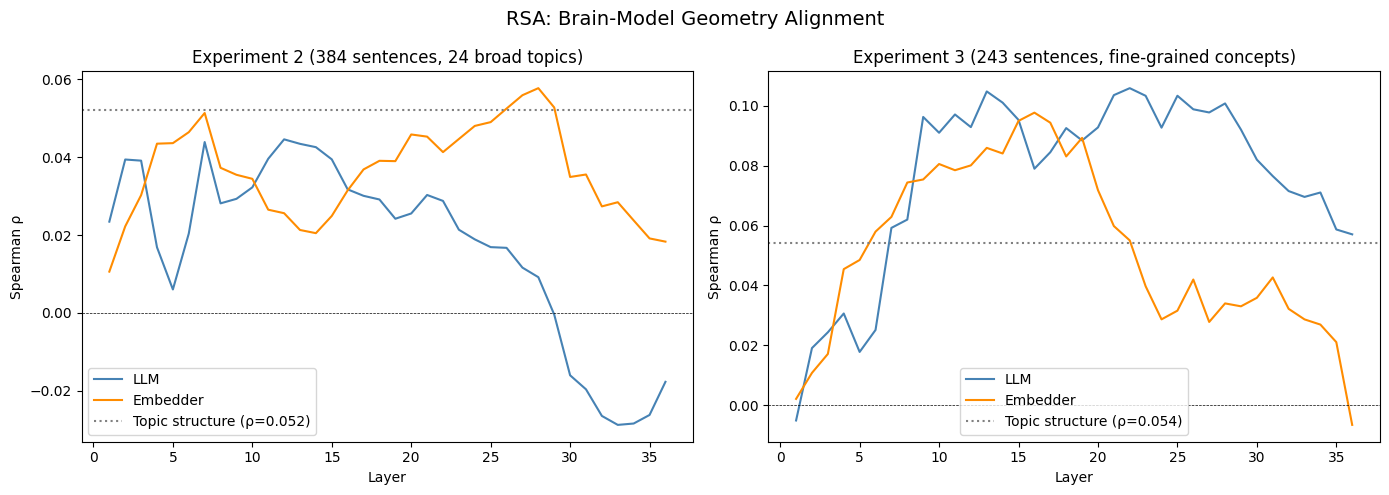

In [ ]:
import matplotlib.pyplot as plt

layers = list(range(1, num_layers)) 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RSA: Brain-Model Geometry Alignment', fontsize=14)

# Experiment 2 
ax = axes[0]
ax.plot(layers, [rsa_llm_exp2[l][0] for l in layers], label='LLM', color='steelblue')
ax.plot(layers, [rsa_emb_exp2[l][0] for l in layers], label='Embedder', color='darkorange')
ax.axhline(topic_brain_rho_exp2, color='gray', linestyle=':', label=f'Topic structure (ρ={topic_brain_rho_exp2:.3f})')
ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_title('Experiment 2 (384 sentences, 24 broad topics)')
ax.set_xlabel('Layer')
ax.set_ylabel('Spearman ρ')
ax.legend()

# Experiment 3 
ax = axes[1]
ax.plot(layers, [rsa_llm_exp3[l][0] for l in layers], label='LLM', color='steelblue')
ax.plot(layers, [rsa_emb_exp3[l][0] for l in layers], label='Embedder', color='darkorange')
ax.axhline(topic_brain_rho_exp3, color='gray', linestyle=':', label=f'Topic structure (ρ={topic_brain_rho_exp3:.3f})')
ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_title('Experiment 3 (243 sentences, fine-grained concepts)')
ax.set_xlabel('Layer')
ax.set_ylabel('Spearman ρ')
ax.legend()

plt.tight_layout()
plt.savefig('rsa_results.png', dpi=150)
plt.show()

Residual Method

In [ ]:
def voxel_encoding(embeddings, fmri, n_splits=5):
    """Returns mean Pearson r across voxels."""
    kf = KFold(n_splits=n_splits)
    correlations = []
    for train_idx, test_idx in kf.split(embeddings):
        X_train, X_test = embeddings[train_idx], embeddings[test_idx]
        y_train, y_test = fmri[train_idx], fmri[test_idx]
        model = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r_per_voxel = [
            np.corrcoef(y_pred[:, v], y_test[:, v])[0, 1]
            for v in range(fmri.shape[1])
        ]
        correlations.append(np.nanmean(r_per_voxel))
    return np.mean(correlations)

In [ ]:
num_layers = 37
layer_embeddings_llm_exp2 = {}
layer_embeddings_llm_exp3 = {}
layer_embeddings_emb_exp2 = {}
layer_embeddings_emb_exp3 = {}

for layer_idx in range(num_layers):
    layer_embeddings_llm_exp2[layer_idx] = np.load(
        os.path.join(llm_dir_exp2, f"qwen_layer{layer_idx}.npy")
    )
    layer_embeddings_llm_exp3[layer_idx] = np.load(
        os.path.join(llm_dir_exp3, f"qwen_layer{layer_idx}.npy")
    )
    layer_embeddings_emb_exp2[layer_idx] = np.load(
        os.path.join(embed_dir_exp2, f"qwen_layer{layer_idx}.npy")
    )
    layer_embeddings_emb_exp3[layer_idx] = np.load(
        os.path.join(embed_dir_exp3, f"qwen_layer{layer_idx}.npy")
    )

print("LLM exp2 layer 0:", layer_embeddings_llm_exp2[0].shape)  # (384, n_dims)
print("LLM exp3 layer 0:", layer_embeddings_llm_exp3[0].shape)  # (243, n_dims)
print("Emb exp2 layer 0:", layer_embeddings_emb_exp2[0].shape)  # (384, n_dims)
print("Emb exp3 layer 0:", layer_embeddings_emb_exp3[0].shape)  # (243, n_dims)

LLM exp2 layer 0: (384, 4096)
LLM exp3 layer 0: (243, 4096)
Emb exp2 layer 0: (384, 4096)
Emb exp3 layer 0: (243, 4096)


In [ ]:
peak_llm_exp2 = 12
peak_emb_exp2 = 28
peak_llm_exp3 = 22
peak_emb_exp3 = 16

# Compute residual embeddings 
res_llm_exp2 = compute_residual_embeddings(
    layer_embeddings_llm_exp2[peak_llm_exp2], topic_labels_exp2
)
res_emb_exp2 = compute_residual_embeddings(
    layer_embeddings_emb_exp2[peak_emb_exp2], topic_labels_exp2
)
res_llm_exp3 = compute_residual_embeddings(
    layer_embeddings_llm_exp3[peak_llm_exp3], topic_labels_exp3
)
res_emb_exp3 = compute_residual_embeddings(
    layer_embeddings_emb_exp3[peak_emb_exp3], topic_labels_exp3
)

print("Residual embeddings computed")
print("LLM exp2 residual shape:", res_llm_exp2.shape)
print("Emb exp3 residual shape:", res_emb_exp3.shape)

Residual embeddings computed
LLM exp2 residual shape: (384, 4096)
Emb exp3 residual shape: (243, 4096)


In [ ]:
print("Running residual voxel encoding... (this may take 10-20 mins)")

# Baseline scores at peak layers for comparison
print("Computing baselines...")
base_llm_exp2 = voxel_encoding(layer_embeddings_llm_exp2[peak_llm_exp2], fmri_exp2)
base_emb_exp2 = voxel_encoding(layer_embeddings_emb_exp2[peak_emb_exp2], fmri_exp2)
base_llm_exp3 = voxel_encoding(layer_embeddings_llm_exp3[peak_llm_exp3], fmri_exp3)
base_emb_exp3 = voxel_encoding(layer_embeddings_emb_exp3[peak_emb_exp3], fmri_exp3)

# Residual scores
print("Computing residuals...")
resid_llm_exp2 = voxel_encoding(res_llm_exp2, fmri_exp2)
resid_emb_exp2 = voxel_encoding(res_emb_exp2, fmri_exp2)
resid_llm_exp3 = voxel_encoding(res_llm_exp3, fmri_exp3)
resid_emb_exp3 = voxel_encoding(res_emb_exp3, fmri_exp3)

print("\n=== Results ===")
print(f"Exp2 LLM  — baseline: {base_llm_exp2:.4f} | residual: {resid_llm_exp2:.4f} | drop: {base_llm_exp2 - resid_llm_exp2:.4f}")
print(f"Exp2 Emb  — baseline: {base_emb_exp2:.4f} | residual: {resid_emb_exp2:.4f} | drop: {base_emb_exp2 - resid_emb_exp2:.4f}")
print(f"Exp3 LLM  — baseline: {base_llm_exp3:.4f} | residual: {resid_llm_exp3:.4f} | drop: {base_llm_exp3 - resid_llm_exp3:.4f}")
print(f"Exp3 Emb  — baseline: {base_emb_exp3:.4f} | residual: {resid_emb_exp3:.4f} | drop: {base_emb_exp3 - resid_emb_exp3:.4f}")

Running residual voxel encoding... (this may take 10-20 mins)
Computing baselines...
Computing residuals...

=== Results ===
Exp2 LLM  — baseline: 0.0436 | residual: 0.0151 | drop: 0.0285
Exp2 Emb  — baseline: 0.0625 | residual: 0.0337 | drop: 0.0288
Exp3 LLM  — baseline: 0.0538 | residual: 0.0361 | drop: 0.0177
Exp3 Emb  — baseline: 0.0448 | residual: 0.0299 | drop: 0.0149


In [ ]:
import matplotlib.pyplot as plt

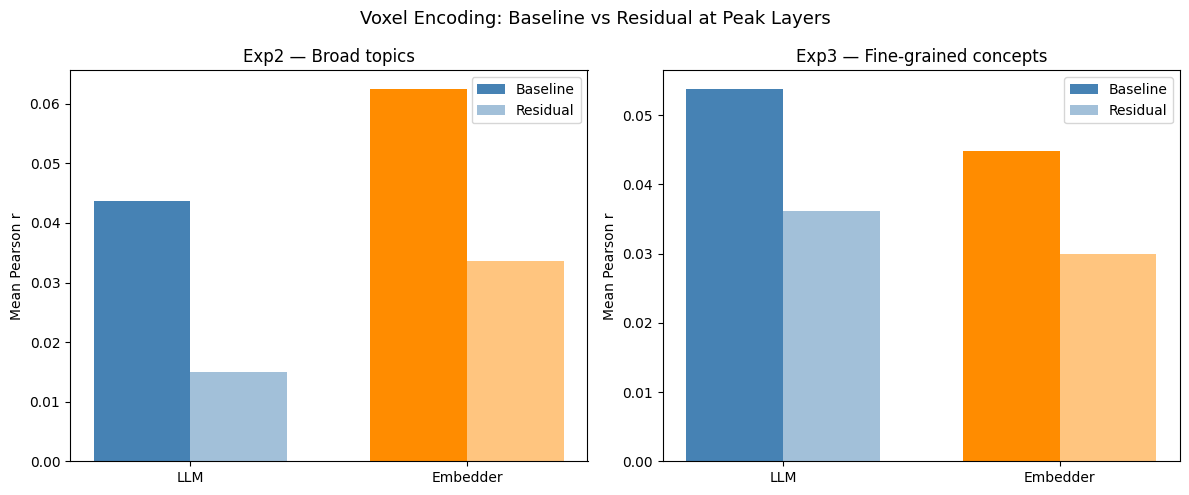

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Voxel Encoding: Baseline vs Residual at Voxel-Encoding Peak Layers', fontsize=13)

for ax, exp, models in zip(axes, ['Exp2', 'Exp3'], [
    [('LLM', base_llm_exp2, resid_llm_exp2),
     ('Embedder', base_emb_exp2, resid_emb_exp2)],
    [('LLM', base_llm_exp3, resid_llm_exp3),
     ('Embedder', base_emb_exp3, resid_emb_exp3)]
]):
    x = np.arange(len(models))
    width = 0.35
    bars1 = ax.bar(x - width/2, [m[1] for m in models], width, 
                   label='Baseline', color=['steelblue', 'darkorange'])
    bars2 = ax.bar(x + width/2, [m[2] for m in models], width,
                   label='Residual', color=['steelblue', 'darkorange'], alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([m[0] for m in models])
    ax.set_ylabel('Mean Pearson r')
    ax.set_title(f'{exp} — {"Broad topics" if exp=="Exp2" else "Fine-grained concepts"}')
    ax.legend()
    ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('residual_results.png', dpi=150)
plt.show()